# Compra de un videojuego (Redes de Bayes)

Actividad basada en probabilidades por frecuencias y Naive Bayes.

Variables:
- Compra (C): Sí/No
- Precio (P): Alto/Medio/Bajo
- Género (G): Acción/Aventura/Estrategia/Otros
- Críticas Positivas (CP): Alta/Baja
- Plataforma (Pl): Consola/PC
- Amigos que lo juegan (A): Sí/No

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder
from sklearn.naive_bayes import CategoricalNB

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
# Simular datos
np.random.seed(42)
n_samples = 100000

data = pd.DataFrame({
    'Precio': np.random.choice(['Alto', 'Medio', 'Bajo'], size=n_samples, p=[0.30, 0.40, 0.30]),
    'Genero': np.random.choice(['Acción', 'Aventura', 'Estrategia', 'Otros'], size=n_samples, p=[0.35, 0.25, 0.20, 0.20]),
    'Criticas': np.random.choice(['Alta', 'Baja'], size=n_samples, p=[0.60, 0.40]),
    'Plataforma': np.random.choice(['Consola', 'PC'], size=n_samples, p=[0.55, 0.45]),
    'Amigos': np.random.choice(['Sí', 'No'], size=n_samples, p=[0.50, 0.50])
})

base = 0.20
precio_adj = {'Alto': -0.08, 'Medio': 0.00, 'Bajo': 0.08}
genero_adj = {'Acción': 0.03, 'Aventura': 0.02, 'Estrategia': 0.01, 'Otros': -0.01}
criticas_adj = {'Alta': 0.10, 'Baja': -0.07}
plataforma_adj = {'Consola': 0.01, 'PC': 0.00}
amigos_adj = {'Sí': 0.12, 'No': -0.05}

p = (
    base
    + data['Precio'].map(precio_adj)
    + data['Genero'].map(genero_adj)
    + data['Criticas'].map(criticas_adj)
    + data['Plataforma'].map(plataforma_adj)
    + data['Amigos'].map(amigos_adj)
)
p = p.clip(0.01, 0.95)

data['Compra'] = np.where(np.random.rand(n_samples) < p, 'Sí', 'No')

data.head()

,Precio,Genero,Criticas,Plataforma,Amigos,Compra
0,Medio,Aventura,Alta,Consola,No,No
1,Bajo,Aventura,Alta,Consola,Sí,Sí
2,Bajo,Aventura,Alta,Consola,Sí,No
3,Medio,Aventura,Alta,Consola,No,No
4,Alto,Aventura,Alta,PC,Sí,No


In [3]:
# Probabilidades condicionales por frecuencias
prob_compra = (
    data.groupby(['Precio', 'Genero', 'Criticas', 'Plataforma', 'Amigos'])['Compra']
    .apply(lambda s: (s == 'Sí').mean())
    .reset_index(name='P(Compra=Sí)')
)

prob_compra.sort_values('P(Compra=Sí)', ascending=False).head(10)

,Precio,Genero,Criticas,Plataforma,Amigos,P(Compra=Sí)
41,Bajo,Aventura,Alta,Consola,Sí,0.537289
33,Bajo,Acción,Alta,Consola,Sí,0.534130
43,Bajo,Aventura,Alta,PC,Sí,0.529703
35,Bajo,Acción,Alta,PC,Sí,0.514447
49,Bajo,Estrategia,Alta,Consola,Sí,0.504451
57,Bajo,Otros,Alta,Consola,Sí,0.502066
59,Bajo,Otros,Alta,PC,Sí,0.497519
51,Bajo,Estrategia,Alta,PC,Sí,0.478368
65,Medio,Acción,Alta,Consola,Sí,0.464148
75,Medio,Aventura,Alta,PC,Sí,0.463811


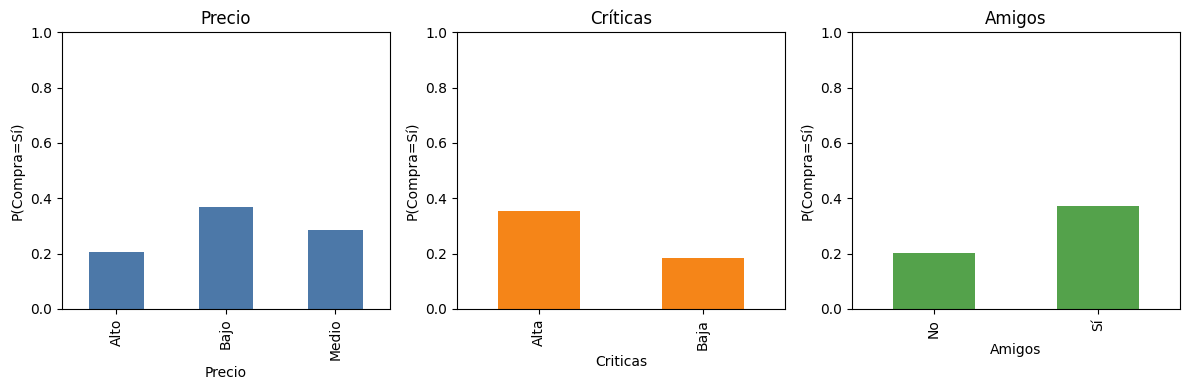

In [4]:
# Visualizar impacto de algunos factores
resumen_precio = data.groupby('Precio')['Compra'].apply(lambda s: (s == 'Sí').mean()).reset_index(name='P(Compra=Sí)')
resumen_criticas = data.groupby('Criticas')['Compra'].apply(lambda s: (s == 'Sí').mean()).reset_index(name='P(Compra=Sí)')
resumen_amigos = data.groupby('Amigos')['Compra'].apply(lambda s: (s == 'Sí').mean()).reset_index(name='P(Compra=Sí)')

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
resumen_precio.plot(kind='bar', x='Precio', y='P(Compra=Sí)', ax=axes[0], legend=False, color='#4C78A8')
resumen_criticas.plot(kind='bar', x='Criticas', y='P(Compra=Sí)', ax=axes[1], legend=False, color='#F58518')
resumen_amigos.plot(kind='bar', x='Amigos', y='P(Compra=Sí)', ax=axes[2], legend=False, color='#54A24B')

axes[0].set_title('Precio')
axes[1].set_title('Críticas')
axes[2].set_title('Amigos')

for ax in axes:
    ax.set_ylim(0, 1)
    ax.set_ylabel('P(Compra=Sí)')

plt.tight_layout()

In [5]:
# Naive Bayes con variables categóricas
encoder = OrdinalEncoder()
X = encoder.fit_transform(data[['Precio', 'Genero', 'Criticas', 'Plataforma', 'Amigos']])
y = data['Compra'].map({'No': 0, 'Sí': 1})

model = CategoricalNB()
model.fit(X, y)

# Ejemplos para estimar probabilidad de compra
combinaciones = pd.DataFrame({
    'Precio': ['Bajo', 'Alto', 'Medio'],
    'Genero': ['Acción', 'Otros', 'Estrategia'],
    'Criticas': ['Alta', 'Baja', 'Alta'],
    'Plataforma': ['Consola', 'PC', 'PC'],
    'Amigos': ['Sí', 'No', 'Sí']
})

X_new = encoder.transform(combinaciones)
probs = model.predict_proba(X_new)

combinaciones['P(Compra=No)'] = probs[:, 0]
combinaciones['P(Compra=Sí)'] = probs[:, 1]

combinaciones

,Precio,Genero,Criticas,Plataforma,Amigos,P(Compra=No),P(Compra=Sí)
0,Bajo,Acción,Alta,Consola,Sí,0.434543,0.565457
1,Alto,Otros,Baja,PC,No,0.927441,0.072559
2,Medio,Estrategia,Alta,PC,Sí,0.571277,0.428723
